# VGSOT Simulation – Cases Guide

This notebook links **physical meaning** and **API usage** for the built-in simulation cases.

Compared with the markdown guide, this notebook also demonstrates the package's **built-in plotting helpers** from `vgsot_sim.result_io`, so users can read results directly as figures instead of inspecting raw arrays.

Recommended usage pattern in each section:

1. create a config or call a case function
2. inspect the returned result object
3. call the built-in plotting helper
4. display the generated figure inline


## Common imports

The helpers below create a local `_notebook_outputs/` directory, save figures with the package's built-in plotting functions, and then display them inline.


In [3]:
from pathlib import Path
from IPython.display import Image, display

from vgsot_sim import (
    ensure_result_dir,
    save_single_plot,
    save_two_panel_plot,
    save_three_panel_plot,
)

OUT_DIR = ensure_result_dir("_notebook_outputs")

def show_png(path):
    display(Image(filename=str(path)))


## 1. Direct SOT switching with piecewise excitation

### Physical meaning

This is the most direct switching experiment:

- an SOT current pulse is applied to the heavy-metal channel
- the free-layer magnetization evolves under the LLG dynamics
- anisotropy, demagnetization, thermal noise, and MTJ resistance feedback are all included in the simulation loop

The low-level API `run_piecewise_direct_excitation(...)` divides the timeline into **three stages**:

- **stage 1**: main write pulse
- **stage 2**: relaxation or intermediate pulse
- **stage 3**: final stabilization

This API is useful when you want to **define the waveform yourself** instead of using a packaged high-level case.


In [2]:
from vgsot_sim import run_piecewise_direct_excitation

res = run_piecewise_direct_excitation(
    sim_start_step=1,
    sim_mid1_step=2000,
    sim_mid2_step=3500,
    sim_end_step=5000,
    pap=1,
    v_mtj_stage1=0.0,
    v_mtj_stage2=0.0,
    v_mtj_stage3=0.0,
    i_sot_stage1=-90e-6,
    i_sot_stage2=0.0,
    i_sot_stage3=0.0,
    estt_stage1=0,
    esot_stage1=1,
    estt_stage2=0,
    esot_stage2=1,
    estt_stage3=0,
    esot_stage3=1,
    vnv=1,
    non=1,
    r_sot_fl_dl=0.83,
)

print(type(res).__name__)
print(res.time_s.shape, res.mz.shape, res.r_mtj.shape)


direct_excitation: 100%|████████████████████████████████████████████████████████| 5000/5000 [00:00<00:00, 31766.27it/s]

SimResult
(5001,) (5001,) (5001,)


### Built-in visualization

For a single time-series result, the package CLI uses `save_three_panel_plot(...)` to show:

- magnetization trajectory `mz(t)`
- MTJ resistance `R_MTJ(t)`
- applied excitation waveform

Below we reproduce that style inside the notebook.


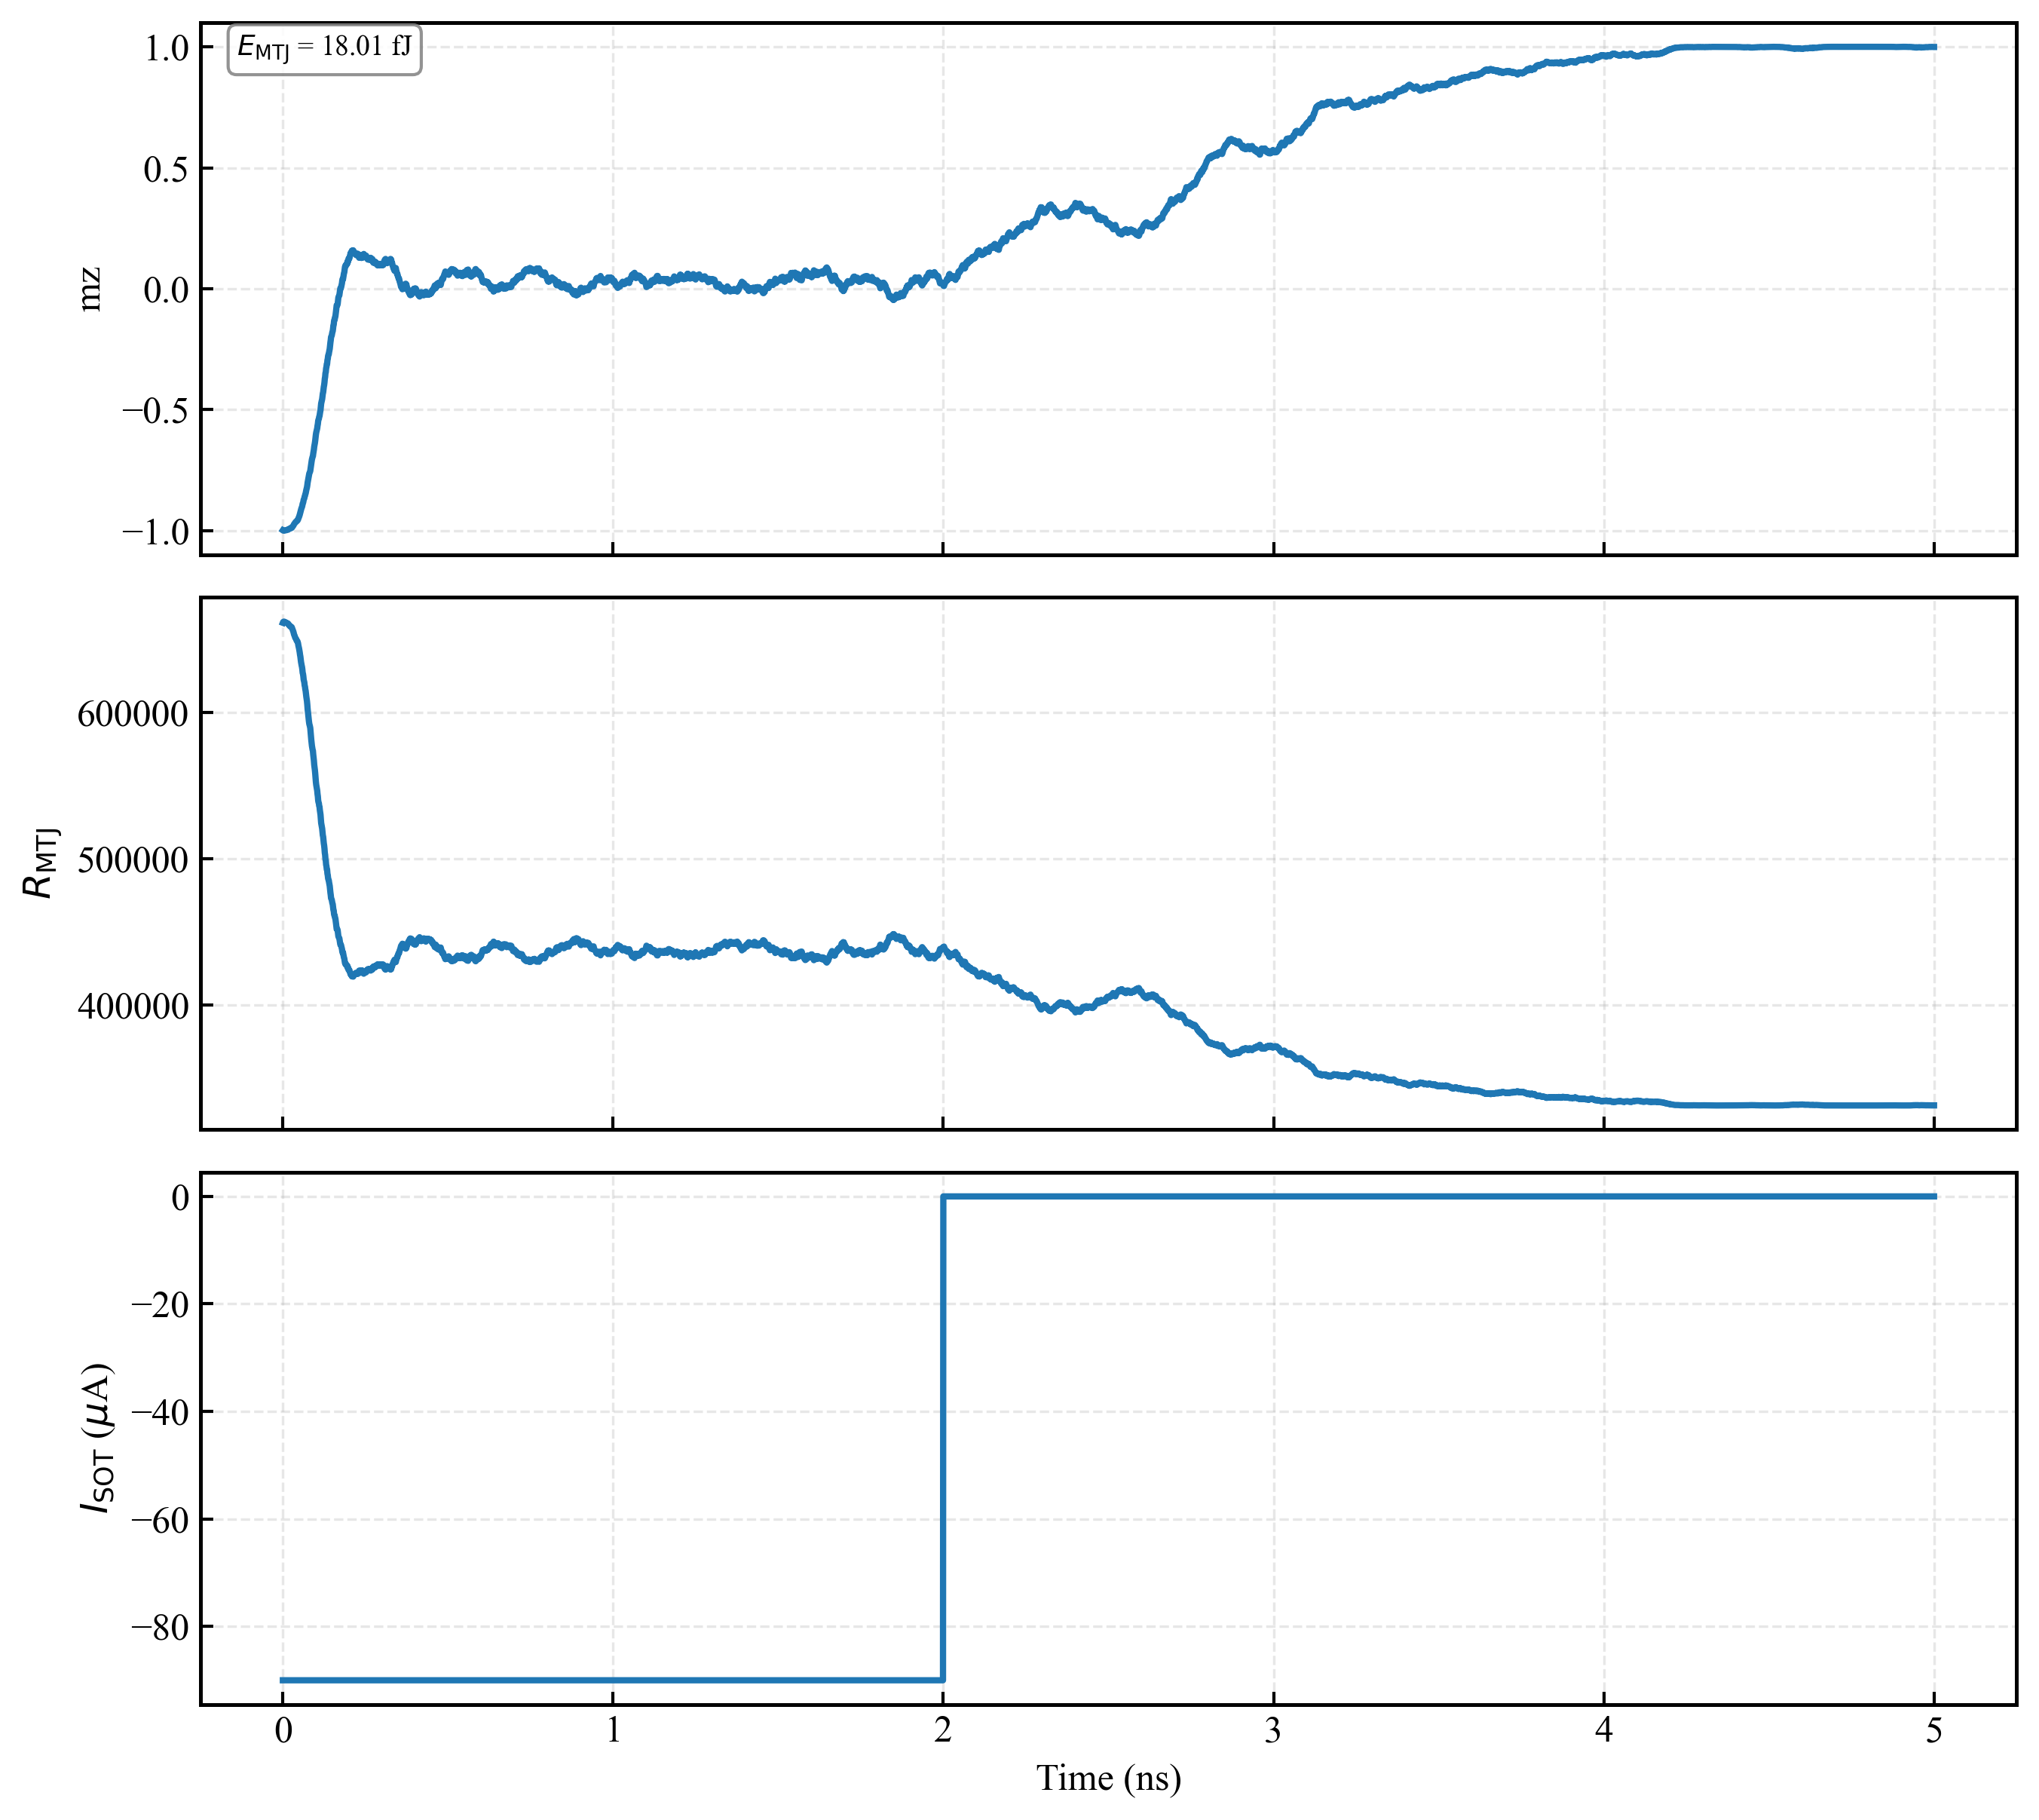

In [3]:
direct_path = OUT_DIR / "direct_piecewise.png"

save_three_panel_plot(
    direct_path,
    res.time_s,
    {"mz": res.mz},
    {r"$R_{\mathrm{MTJ}}$": res.r_mtj},
    {r"$I_{\mathrm{SOT}}$": res.i_sot * 1e6},
    ylabel_top="mz",
    ylabel_mid=r"$R_{\mathrm{MTJ}}$",
    ylabel_bot=r"$I_{\mathrm{SOT}}$ ($\mu$A)",
    x_is_time=True,
    energy_text=f"$E_{{\mathrm{{MTJ}}}}$ = {res.switch_energy_j * 1e15:.2f} fJ",
)

show_png(direct_path)


### How to read the figure

- If `mz` switches from about `+1` to about `-1`, the write pulse succeeds.
- `R_MTJ(t)` follows the magnetization state through the TMR model.
- The bottom panel tells you **what excitation actually caused the switching**.


## 2. Baseline SOT-only switching: constant pulse

### Physical meaning

This case is a **baseline experiment**:

- VCMA is disabled or not used as the control variable
- a constant SOT pulse drives the switching
- the goal is to compare plain SOT switching against VCMA-assisted or optimized schemes

Use this case when you want a clean reference for:
- switching speed
- switching energy
- resistance evolution


In [4]:
from vgsot_sim import sot_only_constant_current, SotOnlyConstantCurrentConfig

cfg = SotOnlyConstantCurrentConfig()
res = sot_only_constant_current(cfg)

print(type(res).__name__)
print(f"switch energy = {res.switch_energy_j * 1e15:.2f} fJ")


direct_excitation: 100%|████████████████████████████████████████████████████████| 5000/5000 [00:00<00:00, 25013.44it/s]

SimResult
switch energy = 20.06 fJ


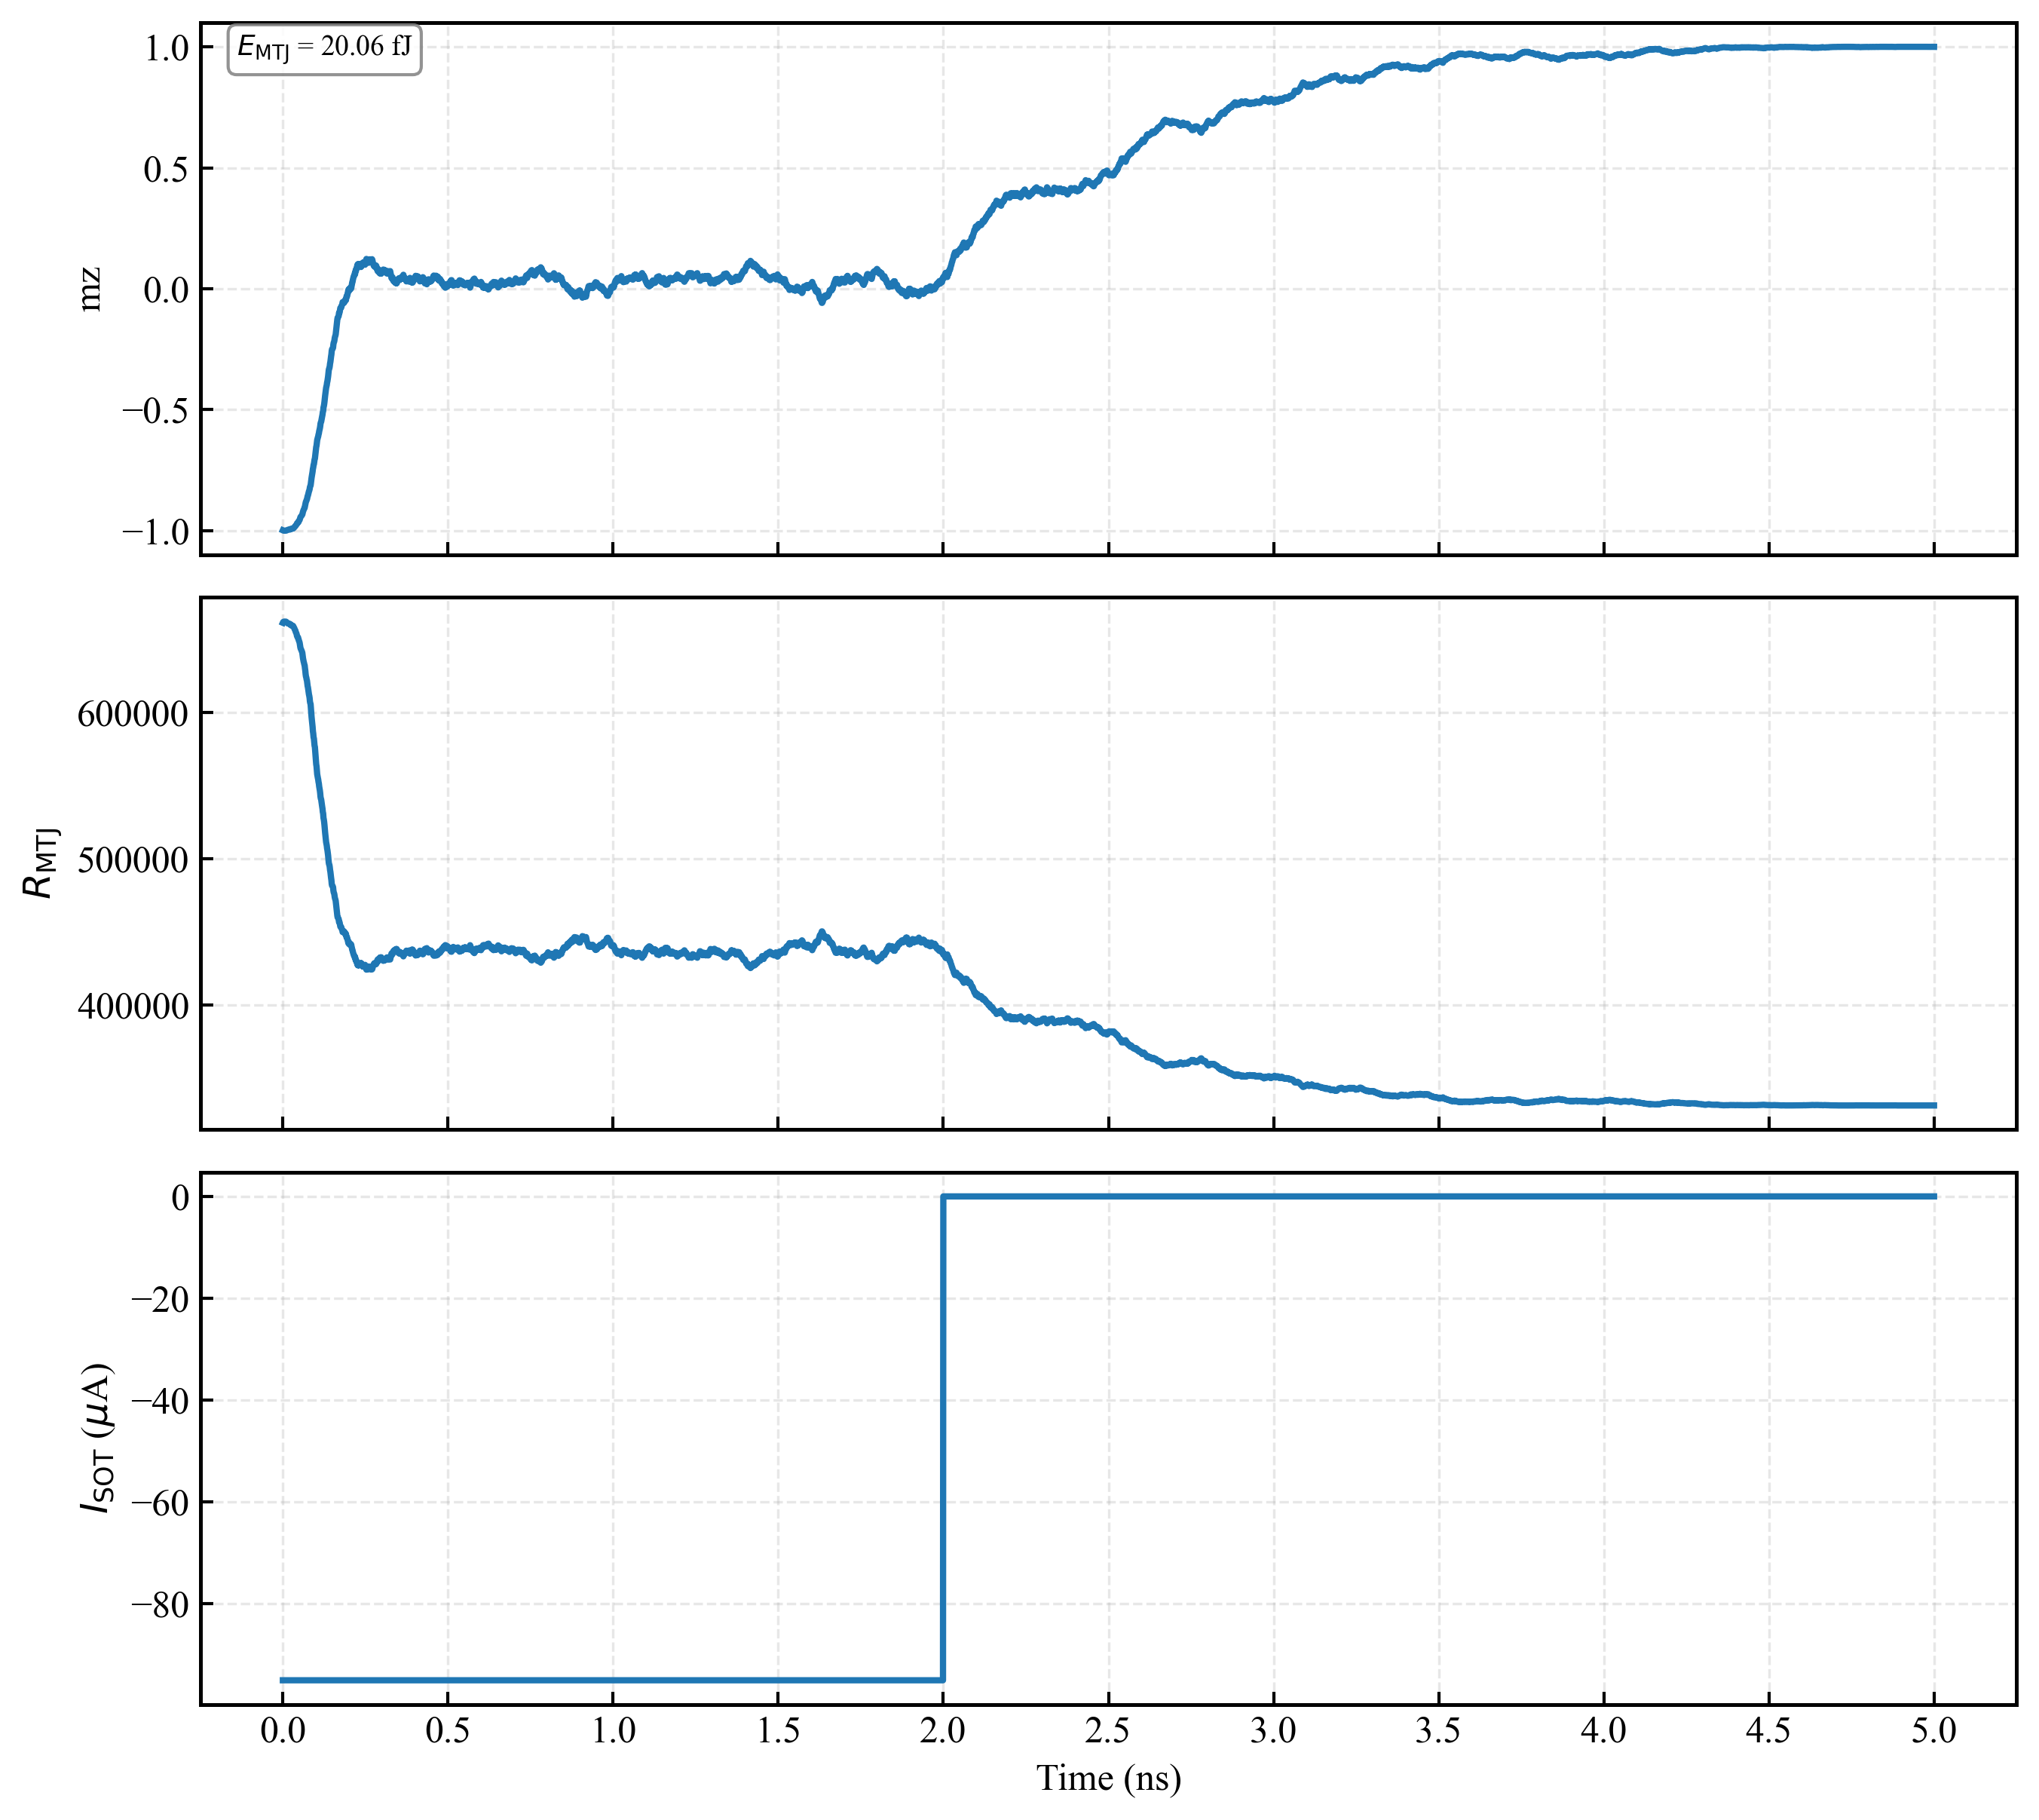

In [5]:
baseline_path = OUT_DIR / "sot_only_constant_current.png"

save_three_panel_plot(
    baseline_path,
    res.time_s,
    {"mz": res.mz},
    {r"$R_{\mathrm{MTJ}}$": res.r_mtj},
    {r"$I_{\mathrm{SOT}}$": res.i_sot * 1e6},
    ylabel_top="mz",
    ylabel_mid=r"$R_{\mathrm{MTJ}}$",
    ylabel_bot=r"$I_{\mathrm{SOT}}$ ($\mu$A)",
    tick_spacing_s=cfg.tick_spacing_s,
    x_is_time=True,
    energy_text=f"$E_{{\mathrm{{MTJ}}}}$ = {res.switch_energy_j * 1e15:.2f} fJ",
)

show_png(baseline_path)


## 3. VCMA-assisted switching: sweep the SOT current

### Physical meaning

In this experiment:

- `V_MTJ` is fixed
- the MTJ voltage changes the anisotropy barrier through the VCMA effect
- `I_SOT` is swept over a list of values
- each value produces one magnetization trajectory

This is a standard way to estimate the **critical current under VCMA assistance**.


In [6]:
from vgsot_sim import (
    vcma_assisted_switching_isot_sweep,
    VcmaAssistedSwitchingIsotSweepConfig,
)

cfg = VcmaAssistedSwitchingIsotSweepConfig(
    v_mtj=1.1,
    i_sot_list=[-40e-6, -30e-6, -20e-6],
)

result = vcma_assisted_switching_isot_sweep(cfg)

print(type(result).__name__)
print(result.time_s.shape)
print(list(result.mz_curves.keys()))


direct_excitation: 100%|██████████████████████████████████████████████████████| 25000/25000 [00:00<00:00, 35578.50it/s]

SweepResult
(25001,)
['I_SOT=-40.0uA', 'I_SOT=-30.0uA', 'I_SOT=-20.0uA']


### Built-in visualization

For sweep-style results, the package uses `save_three_panel_plot(...)` with multiple overlaid curves:

- top: `mz(t)` for each sweep point
- middle: `R_MTJ(t)` for each sweep point
- bottom: pulse waveform for each sweep point


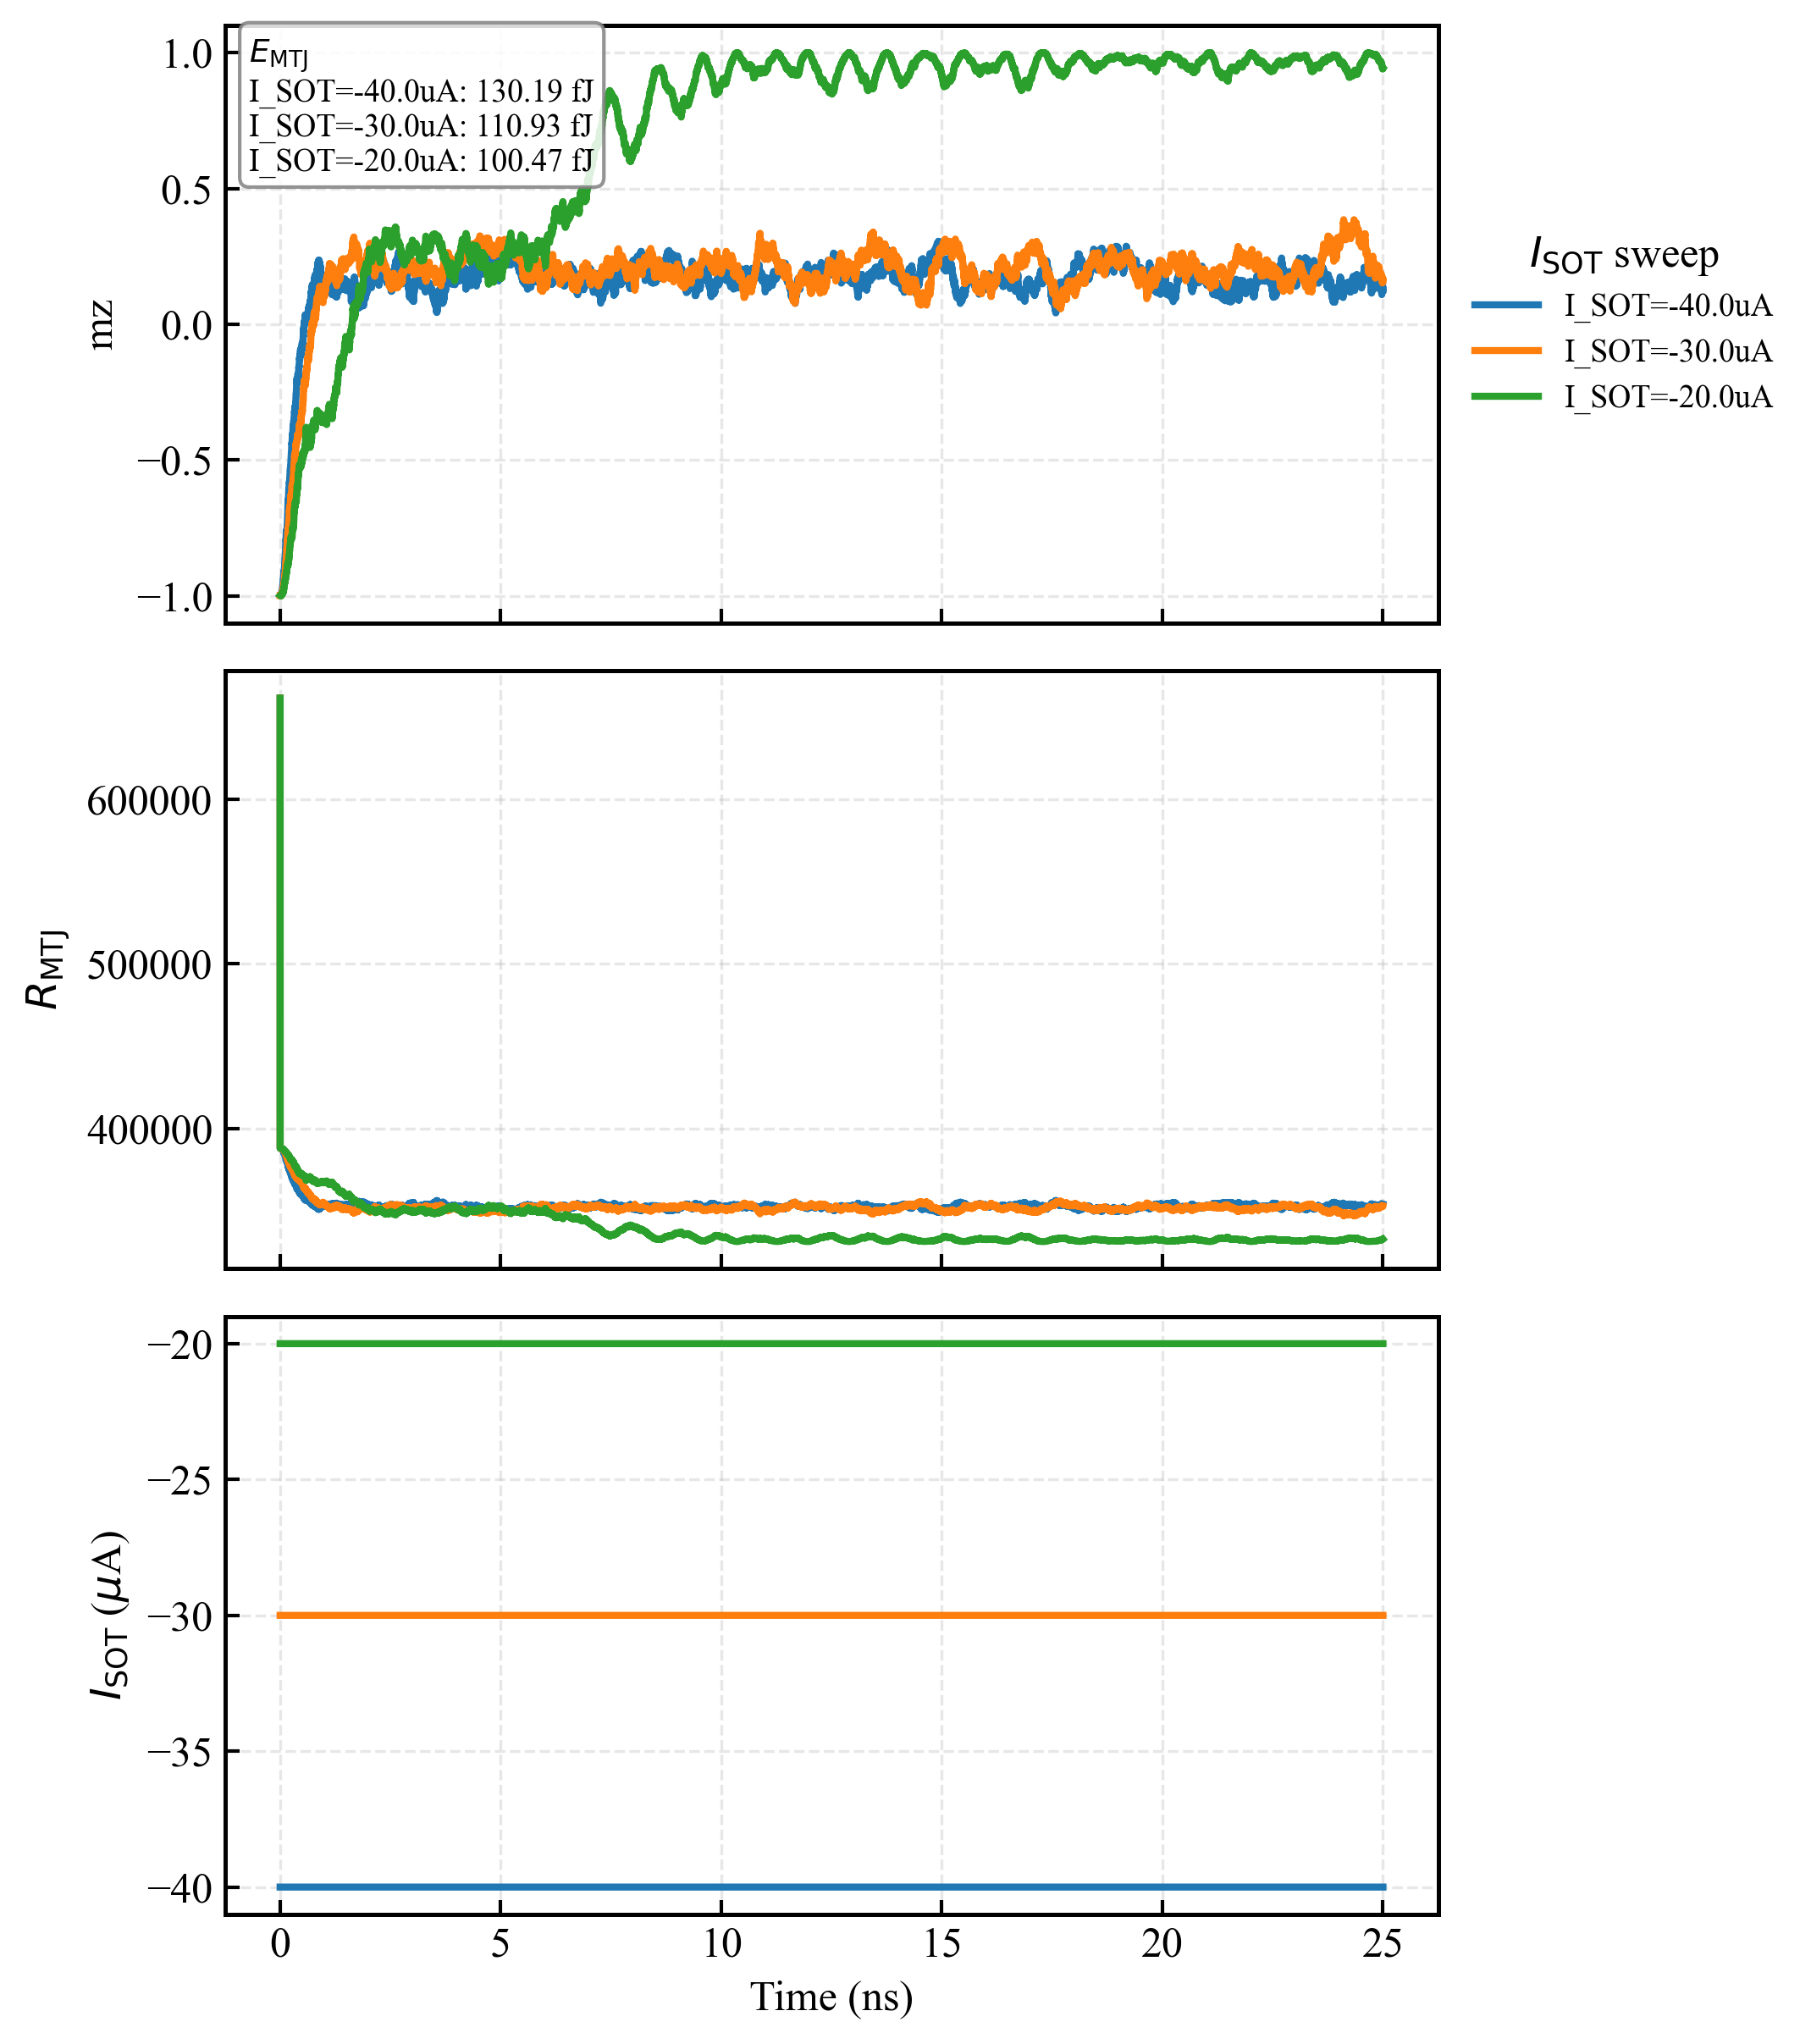

In [7]:
vcma_isot_path = OUT_DIR / "vcma_isot_sweep.png"

energy_text = "\n".join(
    [r"$E_{\mathrm{MTJ}}$"] + [f"{k}: {v * 1e15:.2f} fJ" for k, v in result.switch_energy_j.items()]
)

save_three_panel_plot(
    vcma_isot_path,
    result.time_s,
    result.mz_curves,
    result.r_mtj_curves,
    result.pulse_curves,
    ylabel_top="mz",
    ylabel_mid=r"$R_{\mathrm{MTJ}}$",
    ylabel_bot=result.pulse_ylabel,
    tick_spacing_s=cfg.tick_spacing_s,
    legend_title=r"$I_{\mathrm{SOT}}$ sweep",
    x_is_time=True,
    energy_text=energy_text,
)

show_png(vcma_isot_path)


### How to read the figure

- Curves that cross from `+1` to `-1` indicate successful switching.
- Comparing the labels tells you how much `I_SOT` is needed at the chosen `V_MTJ`.
- The resistance panel helps verify that electrical readout is consistent with the magnetic state.


## 4. VCMA-assisted switching: sweep the MTJ voltage

### Physical meaning

This case keeps `I_SOT` fixed and sweeps `V_MTJ`.

It answers a complementary question:

- how much VCMA assistance is needed for reliable switching?
- how does the barrier reduction change the trajectory and energy?


In [8]:
from vgsot_sim import (
    vcma_assisted_switching_vmtj_sweep,
    VcmaAssistedSwitchingVmtjSweepConfig,
)

cfg = VcmaAssistedSwitchingVmtjSweepConfig()
result = vcma_assisted_switching_vmtj_sweep(cfg)

print(type(result).__name__)
print(list(result.mz_curves.keys())[:3])


direct_excitation: 100%|██████████████████████████████████████████████████████| 25000/25000 [00:00<00:00, 31770.59it/s]

SweepResult
['V_MTJ=1.319V', 'V_MTJ=1.333V', 'V_MTJ=1.349V']


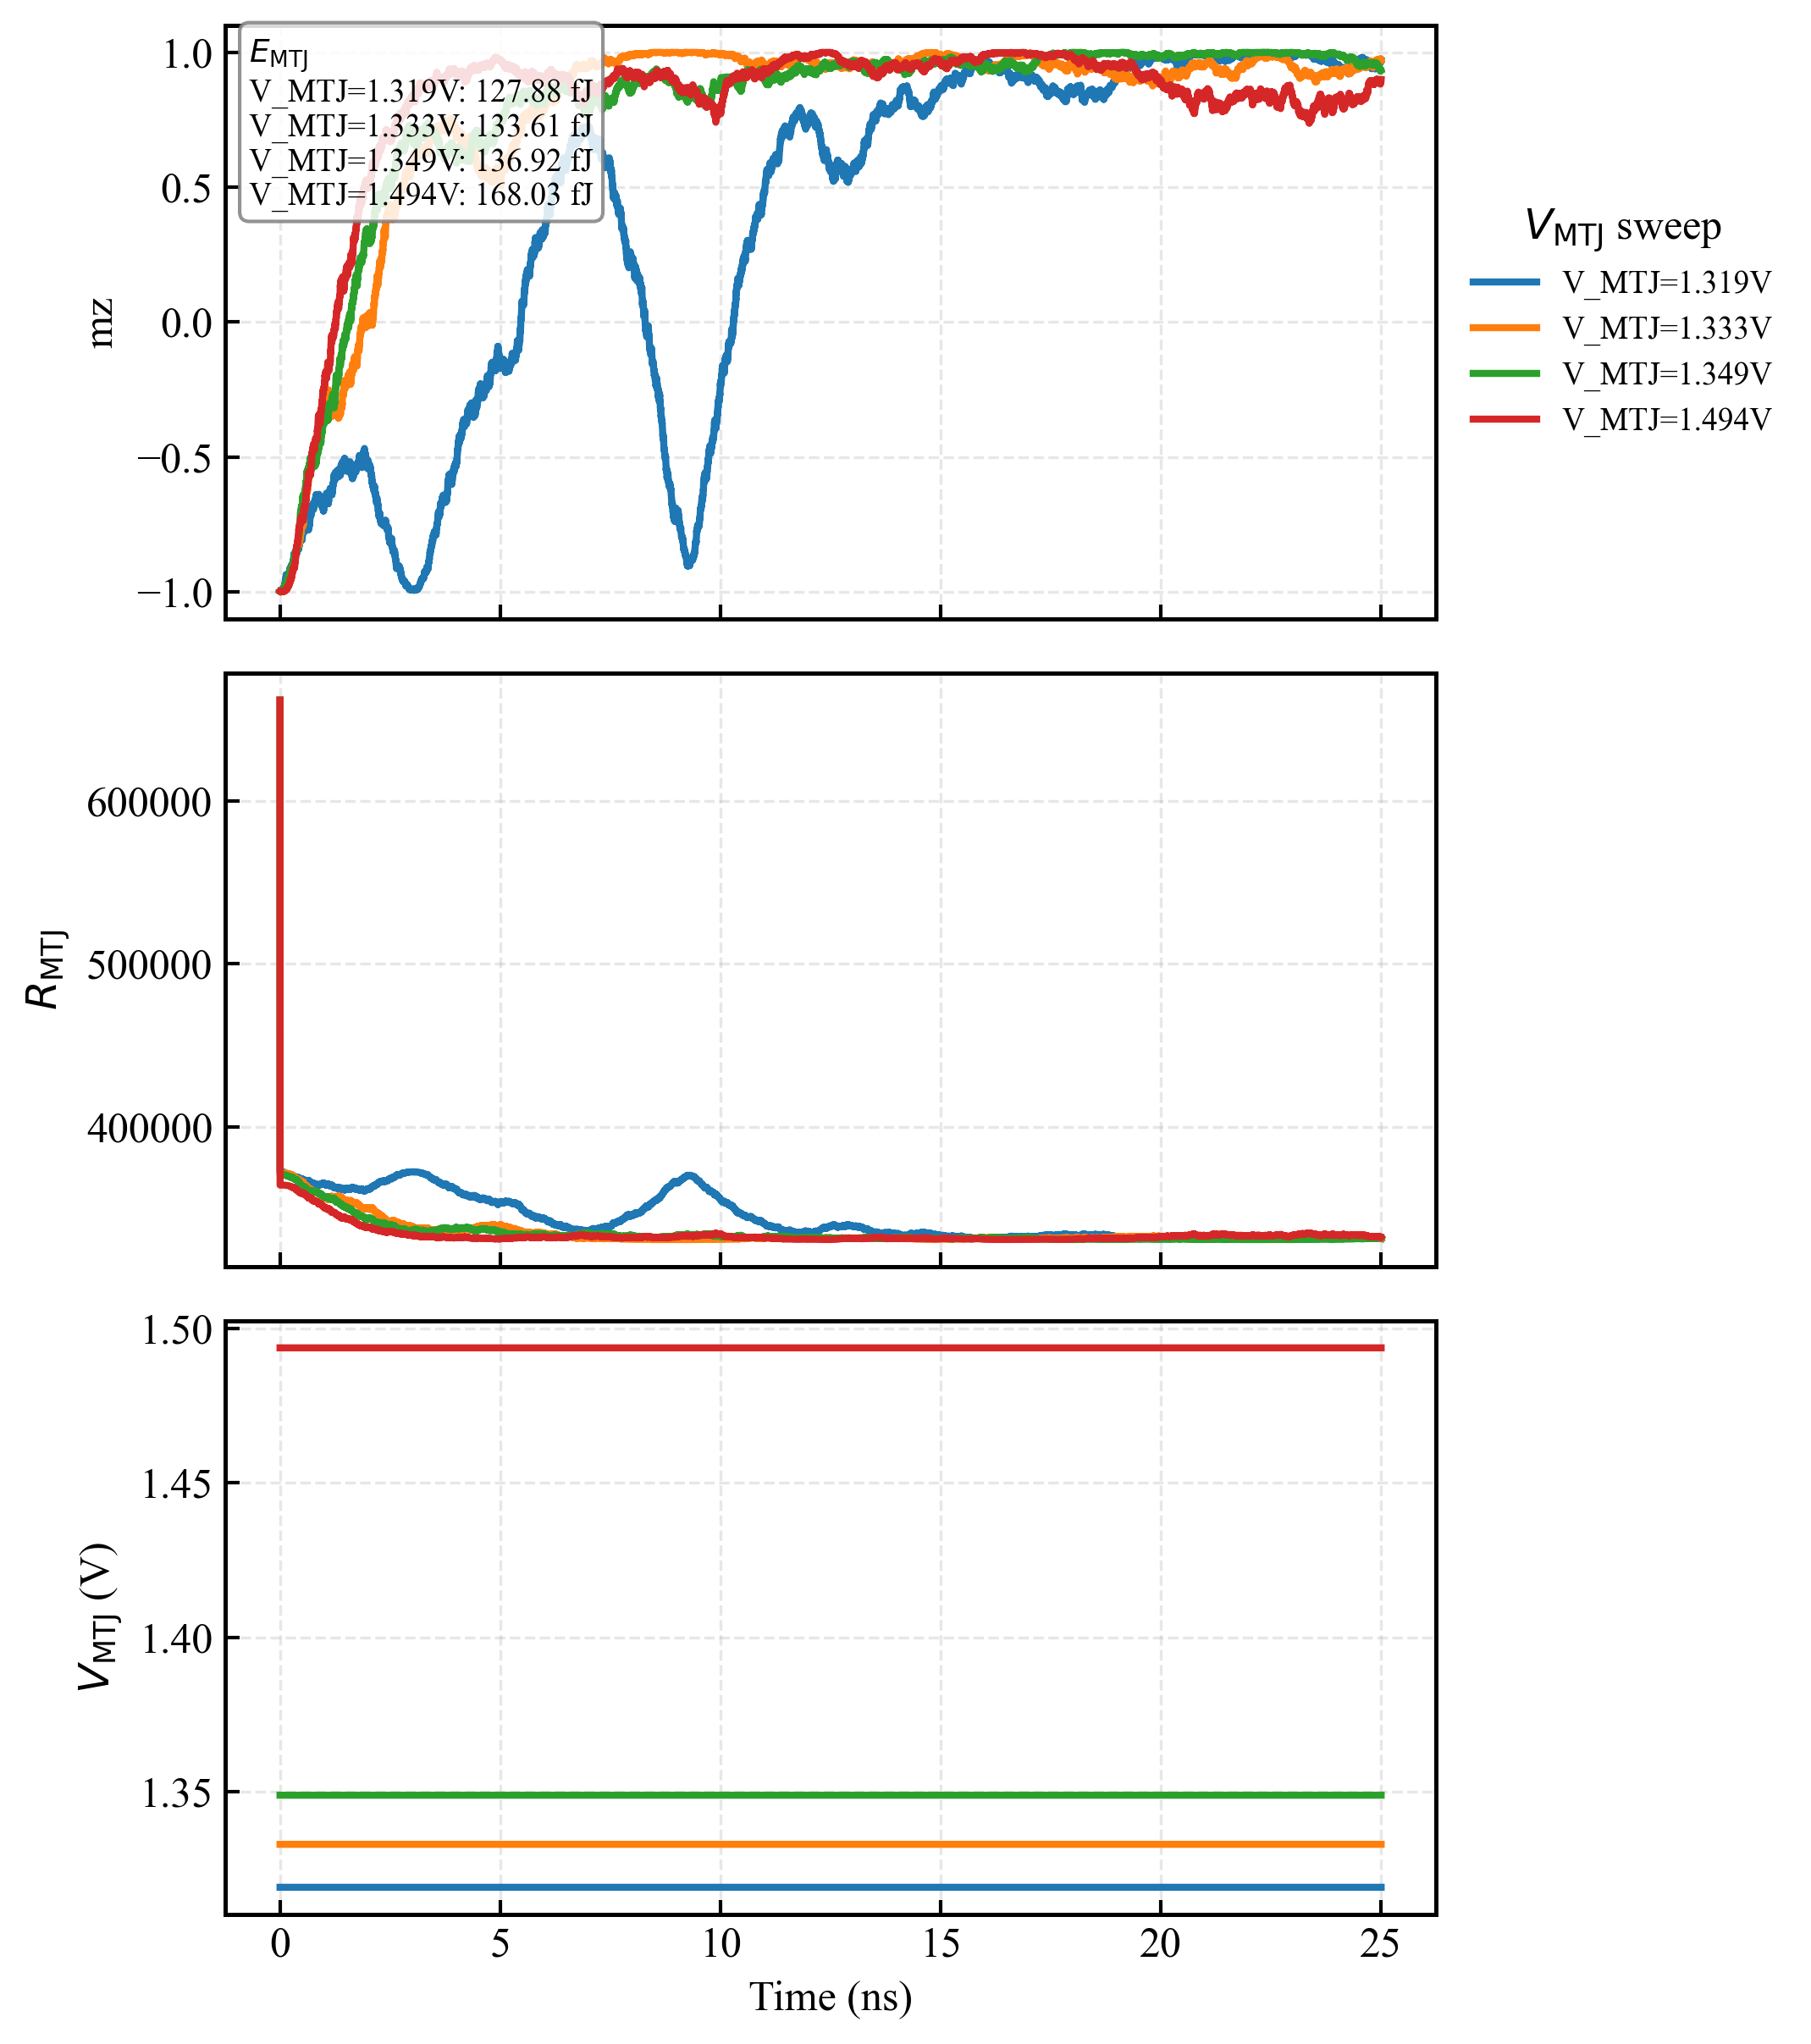

In [9]:
vcma_vmtj_path = OUT_DIR / "vcma_vmtj_sweep.png"

energy_text = "\n".join(
    [r"$E_{\mathrm{MTJ}}$"] + [f"{k}: {v * 1e15:.2f} fJ" for k, v in result.switch_energy_j.items()]
)

save_three_panel_plot(
    vcma_vmtj_path,
    result.time_s,
    result.mz_curves,
    result.r_mtj_curves,
    result.pulse_curves,
    ylabel_top="mz",
    ylabel_mid=r"$R_{\mathrm{MTJ}}$",
    ylabel_bot=result.pulse_ylabel,
    tick_spacing_s=cfg.tick_spacing_s,
    legend_title=r"$V_{\mathrm{MTJ}}$ sweep",
    x_is_time=True,
    energy_text=energy_text,
)

show_png(vcma_vmtj_path)


## 5. Optimized two-pulse VGSOT scheme

### Physical meaning

This case represents the proposed **two-pulse control strategy**:

1. a VCMA-related stage lowers the effective anisotropy barrier
2. a coordinated timing scheme uses pulse widths `(t1, t2)` to improve switching performance

This is the main case to study the **energy-delay tradeoff** of the optimized VGSOT protocol.


In [10]:
from vgsot_sim import optimized_vgsot_switching, OptimizedVgsotSwitchingConfig

cfg = OptimizedVgsotSwitchingConfig()
result = optimized_vgsot_switching(cfg)

print(type(result).__name__)
print(list(result.mz_curves.keys())[:3])


direct_excitation: 100%|██████████████████████████████████████████████████████| 25000/25000 [00:00<00:00, 35173.10it/s]

SweepResult
['t1=25.00ns,t2=0.00ns', 't1=1.40ns,t2=1.60ns', 't1=1.80ns,t2=1.20ns']


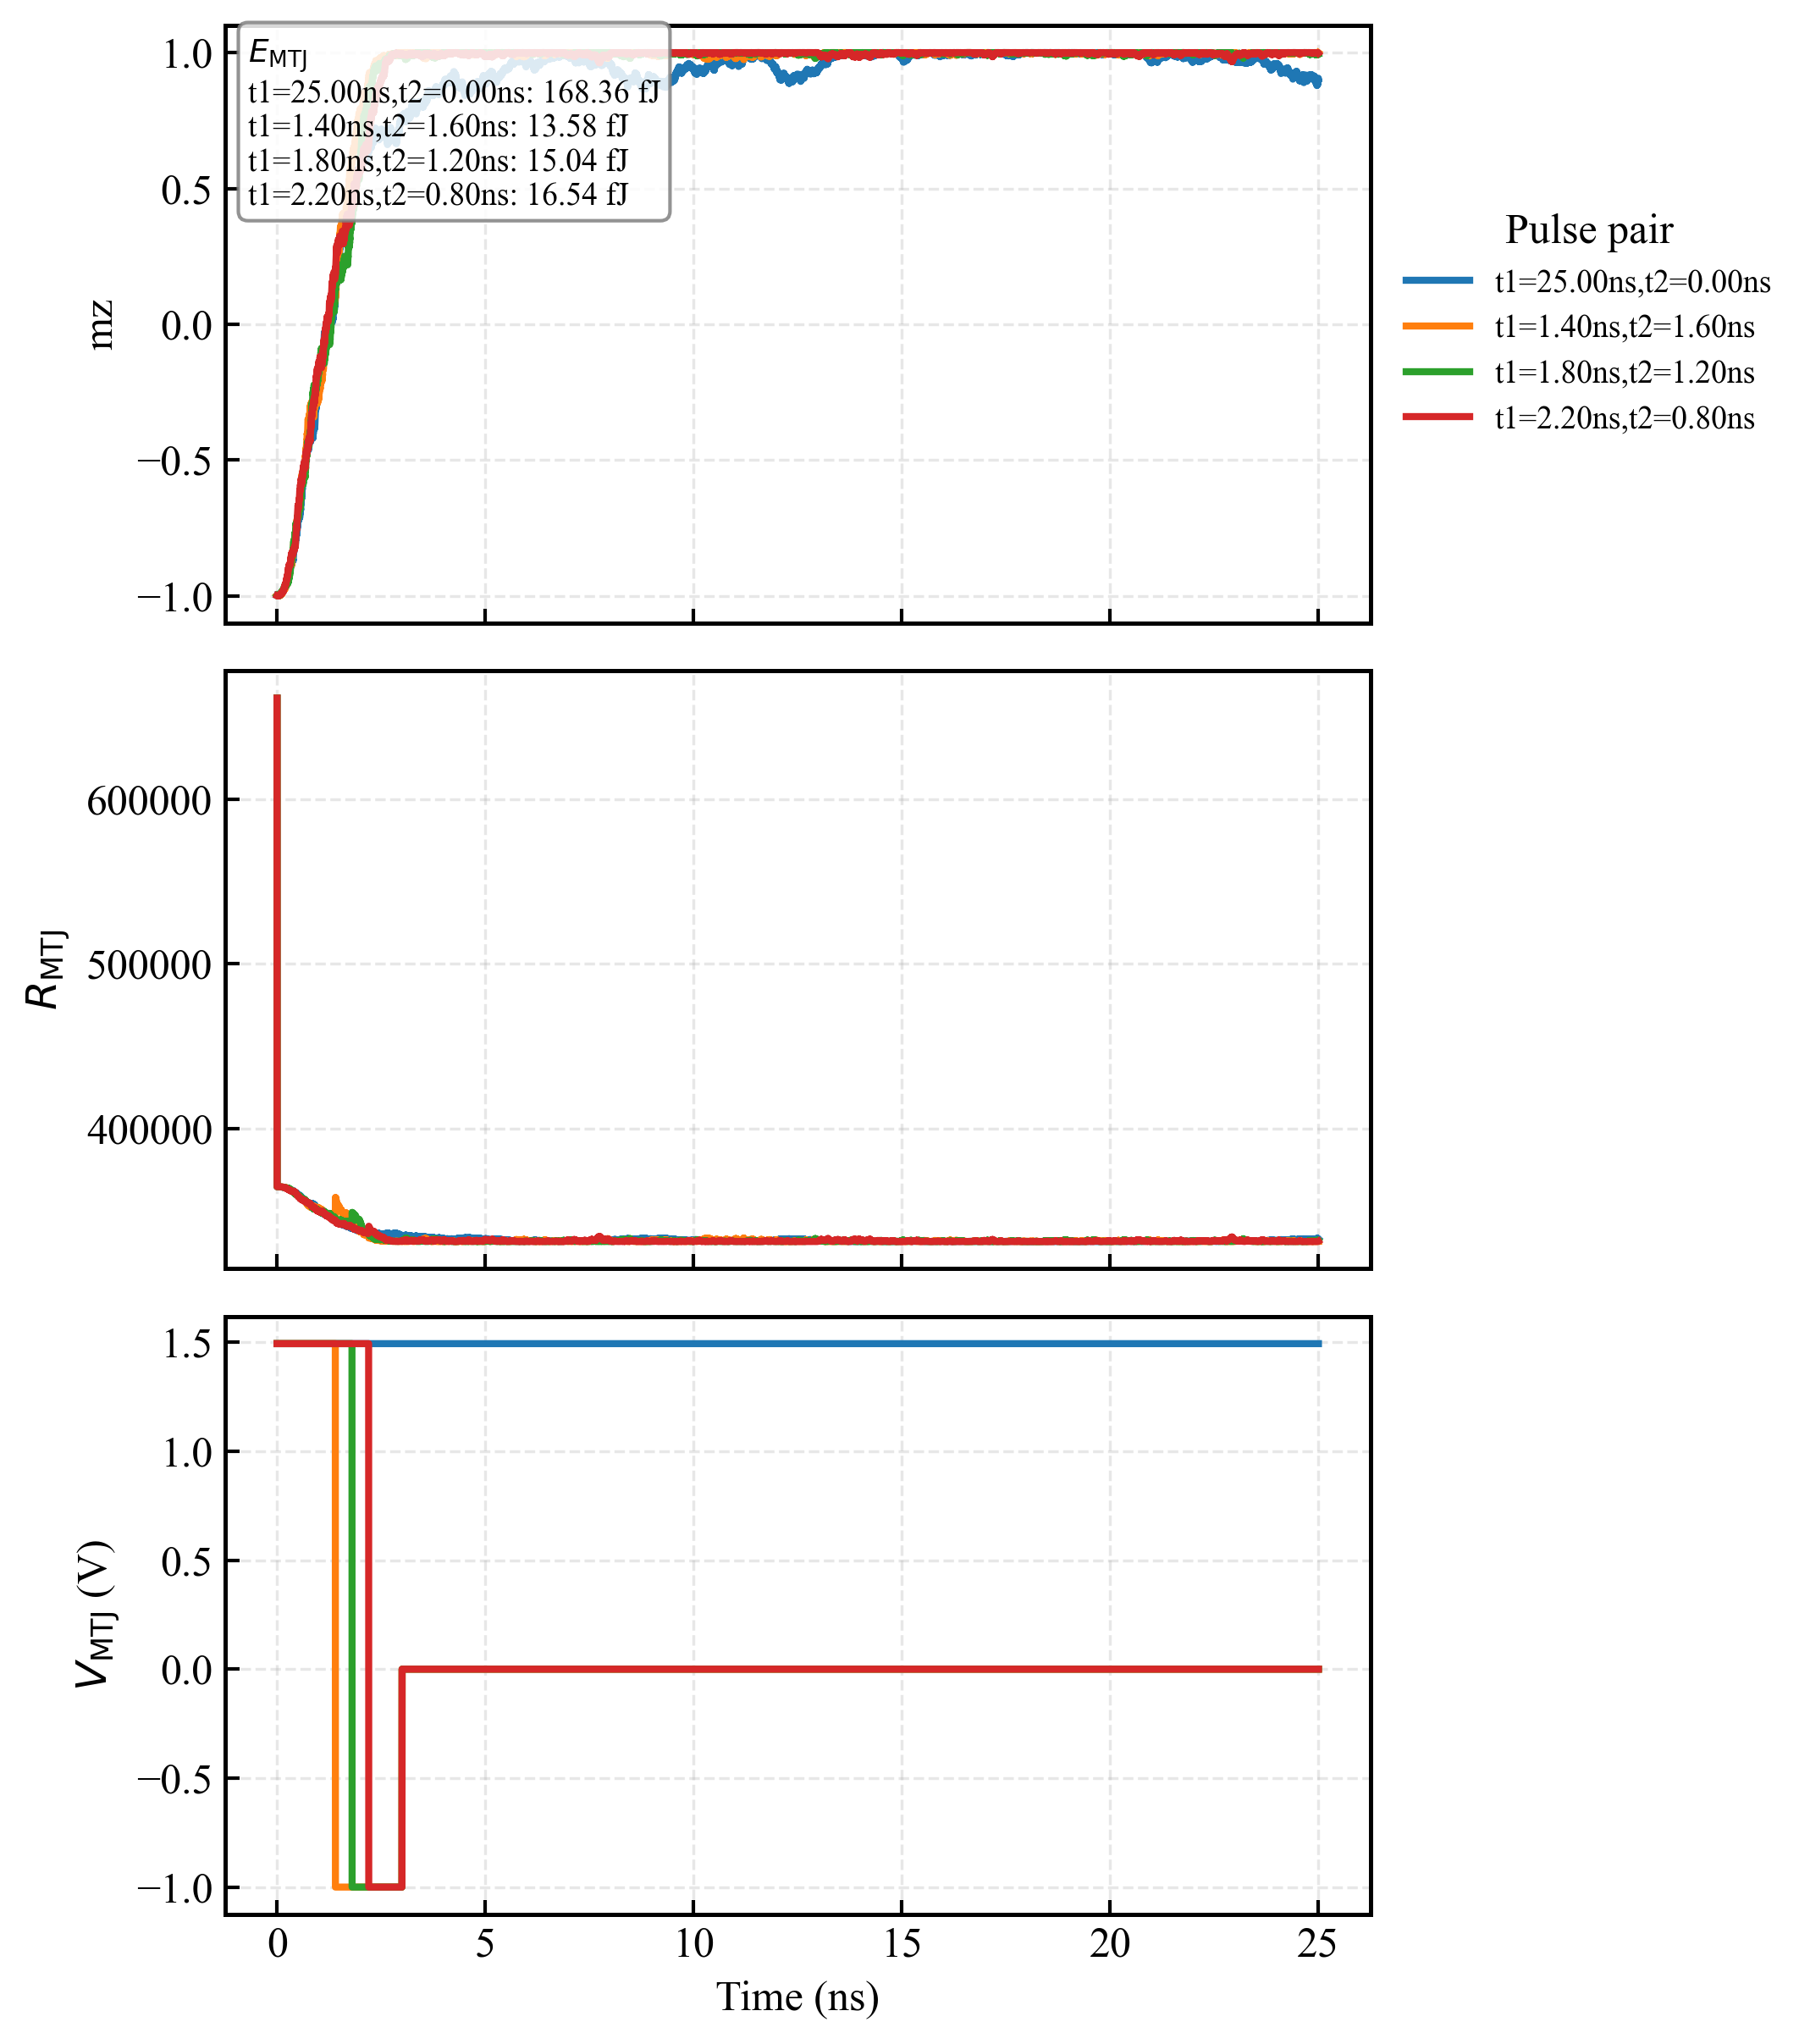

In [11]:
optimized_path = OUT_DIR / "optimized_vgsot_switching.png"

energy_text = "\n".join(
    [r"$E_{\mathrm{MTJ}}$"] + [f"{k}: {v * 1e15:.2f} fJ" for k, v in result.switch_energy_j.items()]
)

save_three_panel_plot(
    optimized_path,
    result.time_s,
    result.mz_curves,
    result.r_mtj_curves,
    result.pulse_curves,
    ylabel_top="mz",
    ylabel_mid=r"$R_{\mathrm{MTJ}}$",
    ylabel_bot=result.pulse_ylabel,
    tick_spacing_s=cfg.tick_spacing_s,
    legend_title="Pulse pair",
    x_is_time=True,
    energy_text=energy_text,
)

show_png(optimized_path)


## 6. SER simulation: reliability under thermal noise

### Physical meaning

SER stands for **switching error rate**.

These experiments repeat the switching process many times under thermal noise and estimate the failure probability:

- lower SER means better write reliability
- the x-axis can be current, voltage, or pulse timing depending on the case

This is the correct tool when the question is not only *can it switch?* but also *can it switch reliably?*


In [12]:
from vgsot_sim import ser_sot_no_vcma_thermal, SerSotNoVcmaThermalConfig

cfg = SerSotNoVcmaThermalConfig()
res = ser_sot_no_vcma_thermal(cfg)

print(type(res).__name__)
print(res.x[:5])
print(res.ser[:5])
print(res.x_label)


MC isot=-9.000e-05A: 100%|█████████████████████████████████████████████████████████| 1000/1000 [02:36<00:00,  6.40it/s]

SerResult
[-1.0e-04 -9.8e-05 -9.6e-05 -9.4e-05 -9.2e-05]
[0.822 0.782 0.778 0.662 0.454]
$I_{\mathrm{SOT}}$ (A)


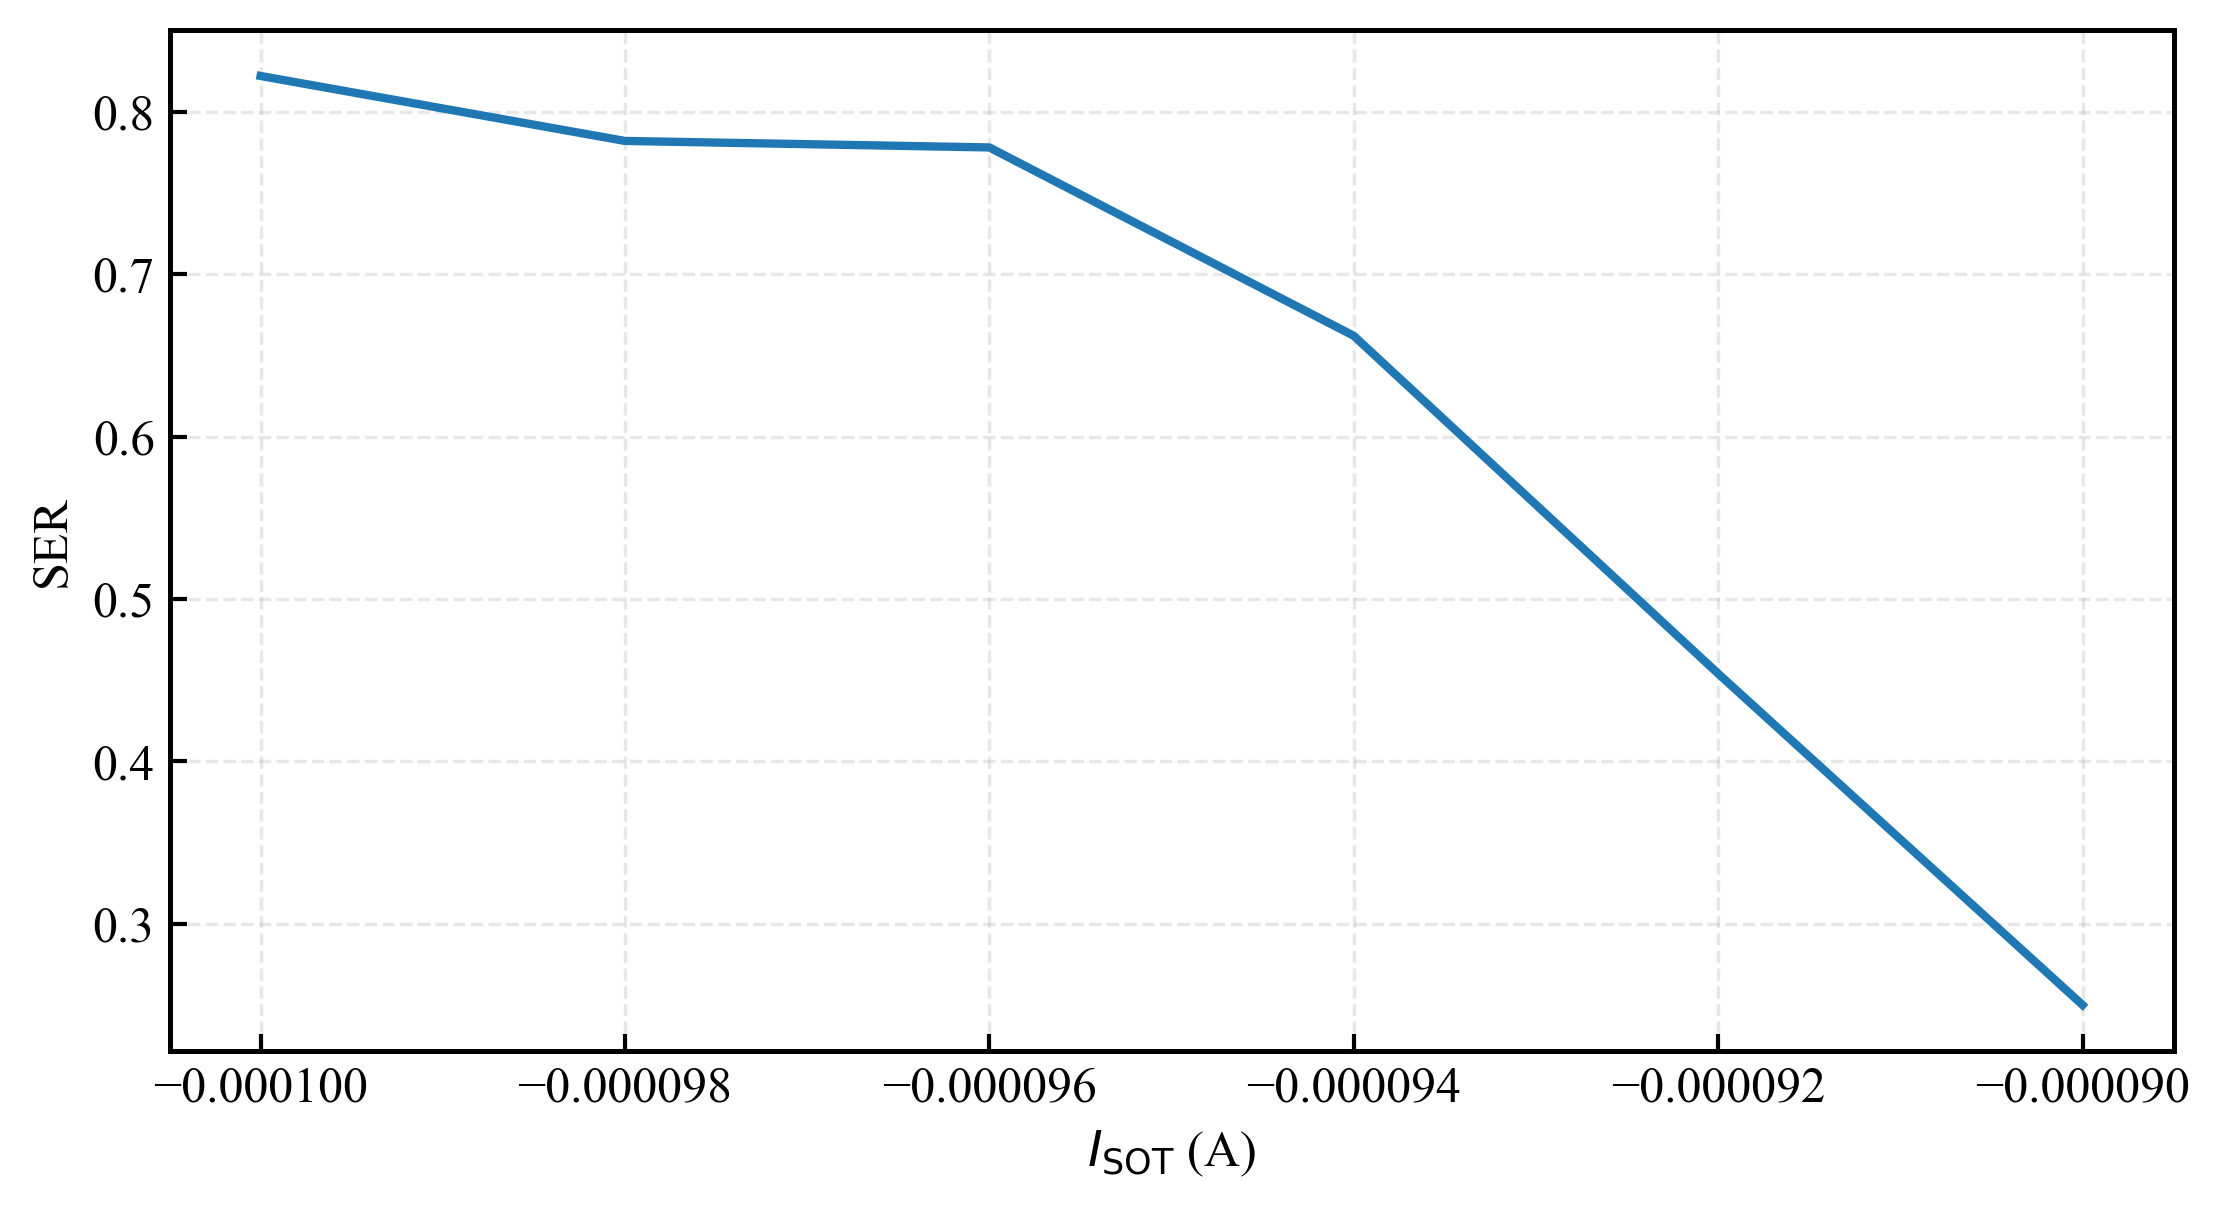

In [13]:
ser_path = OUT_DIR / "ser_sot_no_vcma_thermal.png"

save_single_plot(
    ser_path,
    res.x,
    {"SER": res.ser},
    xlabel=res.x_label,
    ylabel="SER",
    x_is_time=False,
)

show_png(ser_path)


### How to read the SER curve

- A downward trend means the operating point becomes more reliable.
- The useful design region is usually where SER falls below your target threshold.
- This plot is often used together with the time-domain switching figures above.


## 7. Two-pulse low-level API

### Physical meaning

`run_two_pulse_optimized(...)` is the low-level kernel behind the optimized scheme.

Use it when you want to set:
- pulse width `t1`
- pulse width `t2`
- stage voltages
- stage currents
- total simulated time

This API is the most direct way to build your own **custom two-pulse protocol**.


In [1]:
from vgsot_sim import run_two_pulse_optimized

res = run_two_pulse_optimized(
    t1_s=1.5e-9,
    t2_s=1.5e-9,
    v_mtj_1=1.5,
    v_mtj_2=-1.0,
    i_sot_1=-100e-6,
    i_sot_2=0.0,
    sim_total_time_s=25e-9,
    pap=1,
    non=1,
    vnv=1,
    r_sot_fl_dl=0.0,
)

print(type(res).__name__)
print(res.time_s.shape)

direct_excitation: 100%|██████████████████████████████████████████████████████| 25000/25000 [00:00<00:00, 34046.80it/s]

SimResult
(25001,)


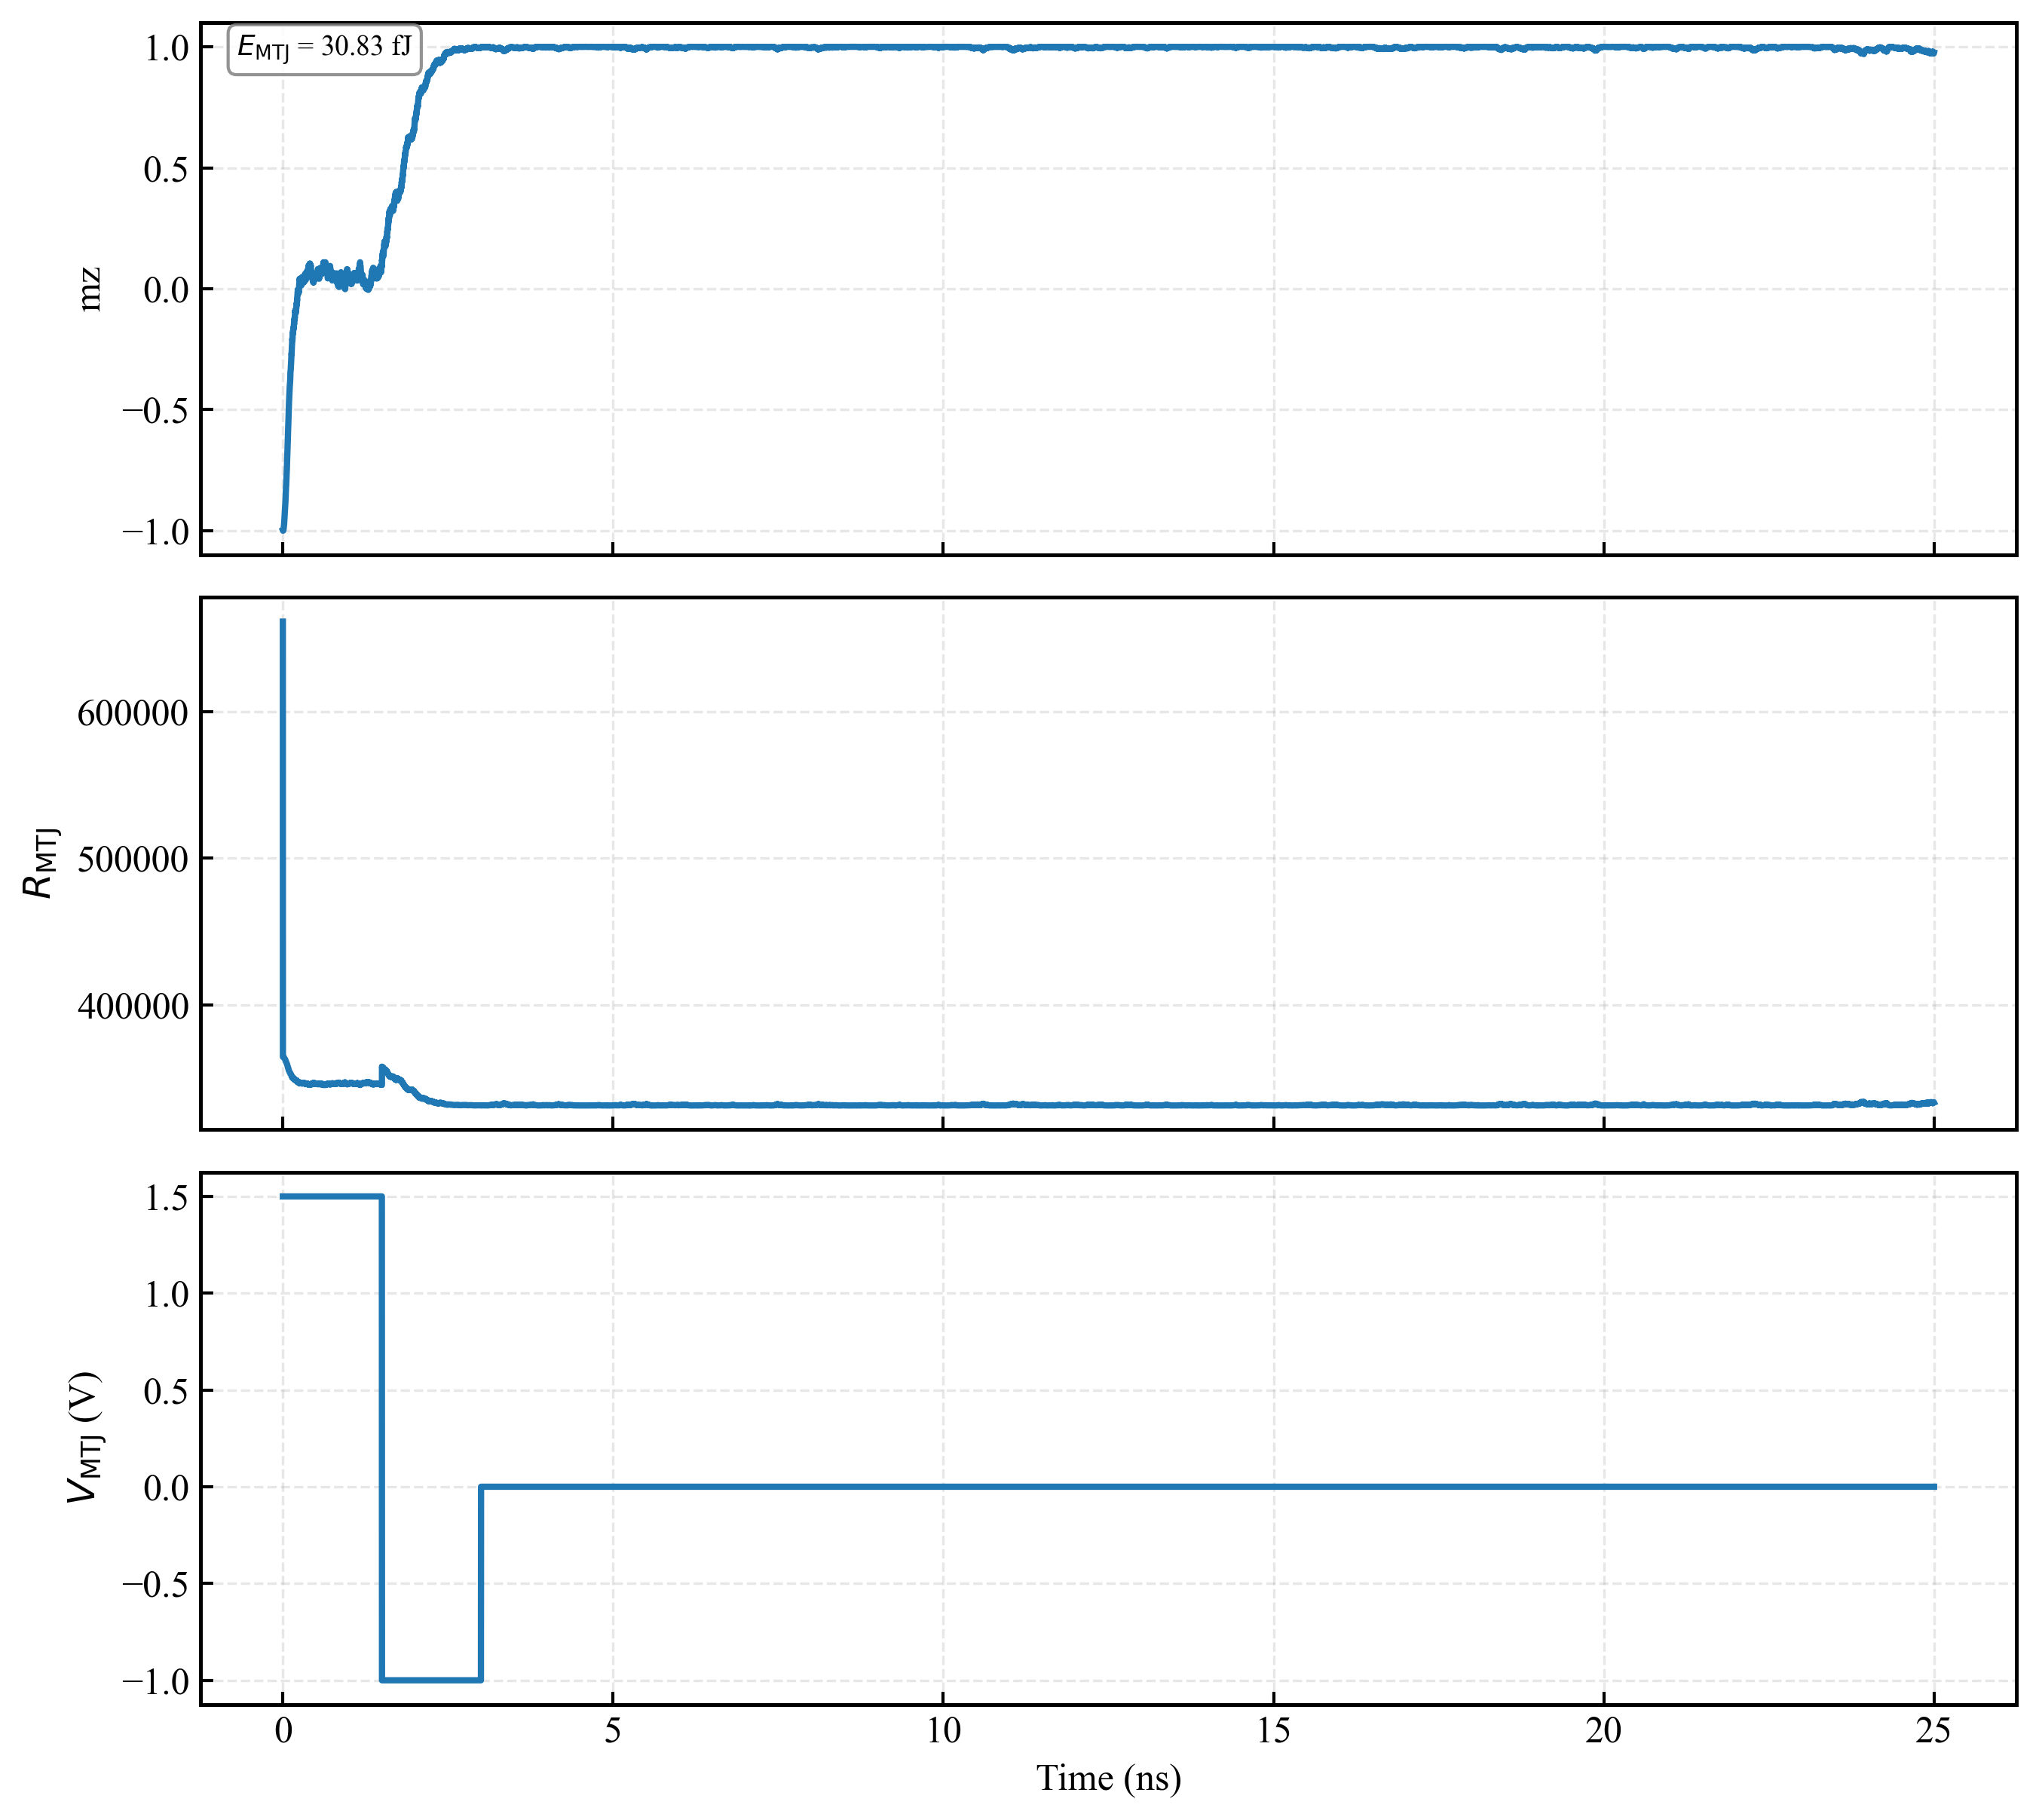

In [4]:
two_pulse_path = OUT_DIR / "two_pulse_optimized.png"

save_three_panel_plot(
    two_pulse_path,
    res.time_s,
    {"mz": res.mz},
    {r"$R_{\mathrm{MTJ}}$": res.r_mtj},
    {r"$V_{\mathrm{MTJ}}$": res.v_mtj},
    ylabel_top="mz",
    ylabel_mid=r"$R_{\mathrm{MTJ}}$",
    ylabel_bot=r"$V_{\mathrm{MTJ}}$ (V)",
    x_is_time=True,
    energy_text=f"$E_{{\mathrm{{MTJ}}}}$ = {res.switch_energy_j * 1e15:.2f} fJ",
)

show_png(two_pulse_path)


## 8. Which API should I use?

| Goal | Recommended API |
|---|---|
| Reproduce a built-in demo case | `terminal_voltage_control`, `sot_only_constant_current`, `vcma_assisted_switching_isot_sweep`, ... |
| Sweep one physical variable with a ready-made workflow | one of the high-level case functions in `vgsot_sim` |
| Define your own time-segmented excitation | `run_piecewise_direct_excitation(...)` |
| Define a custom terminal-voltage waveform | `run_piecewise_terminal_voltage(...)` |
| Study the proposed two-pulse method directly | `run_two_pulse_optimized(...)` |
| Evaluate reliability under thermal noise | `ser_sot_no_vcma_thermal(...)` or `ser_optimized_vgsot(...)` |

In general:

- start from a **high-level case** when learning the package
- move to the **low-level piecewise APIs** when you need custom waveforms
- use the **built-in plotting helpers** to keep figures consistent with the CLI outputs


## 9. Notes

- `SweepResult` exposes `mz_curves`, `r_mtj_curves`, and `pulse_curves`. If you see old examples using `result.curves`, treat it as a compatibility alias for `mz_curves`.
- `run_piecewise_direct_excitation(...)` requires `sim_mid2_step` because the current implementation uses **three stages**.
- The plotting helpers used in this notebook come from `vgsot_sim.result_io` and are re-exported by `vgsot_sim`.
